In [1]:
import os
from dotenv import load_dotenv
from mp_api.client import MPRester
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Retrieving SummaryDoc documents:   0%|          | 0/1606 [00:00<?, ?it/s]

✅ Successfully queried 1606 binary oxides.

  Material ID Formula  Bandgap (eV) Dominant Element
0  mp-1950989     BaO        2.5282               Ba
1  mp-1974948    Na2O        2.6124               Na
2  mp-1974703     FeO        0.5489               Fe
3  mp-1975297    Na2O        1.6667               Na
4  mp-1974672     K2O        1.3904                K


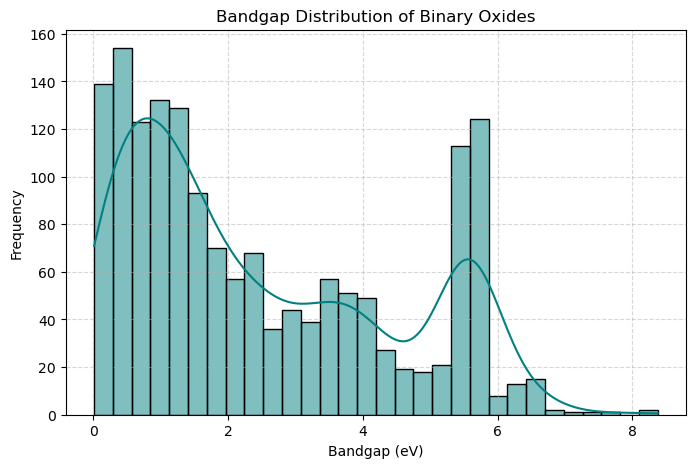

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mp_api.client import MPRester

api_key = "yG9MO3EiaegBkJOVJauCFubkj8QJgeGr"  # Replace with your Materials Project API key

try:
    with MPRester(api_key) as mpr:
        # Step 1: Query binary oxides with band gaps
        docs = mpr.materials.summary.search(
            elements=["O"],
            num_elements=(2, 2),
            band_gap=(0.01, None),  # Only materials with a non-zero band gap
            fields=["material_id", "formula_pretty", "band_gap", "elements"]
        )

        # Step 2: Extract data into a DataFrame
        data_list = []

        for doc in docs:
            elements_list = [str(el) for el in doc.elements]
            dominant_element = [el for el in elements_list if el != "O"][0]

            data_list.append({
                "Material ID": str(doc.material_id),
                "Formula": doc.formula_pretty,
                "Bandgap (eV)": doc.band_gap,
                "Dominant Element": dominant_element
            })

    df = pd.DataFrame(data_list)

    print(f"✅ Successfully queried {len(df)} binary oxides.\n")
    print(df.head())

    # Step 3: Visualize the Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df["Bandgap (eV)"], bins=30, kde=True, color="teal")
    plt.title("Bandgap Distribution of Binary Oxides")
    plt.xlabel("Bandgap (eV)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

except Exception as e:
    print(f"❌ Query Failed: {e}")